In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import torch
from torch import nn
from Datasets.datasetPretrain import WaveletPretrainDataset, WaveletPretrainConcatDataset
from Model.MENDR.WaveletLoss import WaveletReconstructionLoss
from Model.MENDR.Autoencoder.MENDREncoder import GNNSpatialHarmonizer, MENDRPatchEncoder
from Model.MENDR.mAtt.optimizer import MixOptimizer
import matplotlib.pyplot as plt
import tqdm

from torch_geometric.loader import DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [18]:
dataset = WaveletPretrainDataset(root="/storage/ice1/shared/bmed6780/mip_group_6/ef/TUH-128Hz", frac=0.4)

Loading 5276 subjects


100%|██████████| 5276/5276 [04:02<00:00, 21.77it/s]


In [19]:
models = nn.ParameterDict({
    'delta': GNNSpatialHarmonizer(num_channels=19, num_features=8, device=device, n_gnn_transformer_layers=3, heads=2),
    'theta': GNNSpatialHarmonizer(num_channels=19, num_features=8, device=device, n_gnn_transformer_layers=3, heads=2),
    'alpha': GNNSpatialHarmonizer(num_channels=19, num_features=16, device=device, n_gnn_transformer_layers=3, heads=2),
    'beta': GNNSpatialHarmonizer(num_channels=19, num_features=32, device=device, n_gnn_transformer_layers=3, heads=2),
    'gamma': GNNSpatialHarmonizer(num_channels=19, num_features=64, device=device, n_gnn_transformer_layers=3, heads=2),
}).to(device)

In [5]:
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=32)

In [6]:
epochs = 5
optimizer = torch.optim.AdamW(models.parameters(),
            betas=(0.9, 0.99),
            lr=1.0e-3,
            weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
            T_max=epochs,
            eta_min=1.0e-7)
mix_optimizer = MixOptimizer(optimizer, scheduler)

In [15]:
SUPPORTED_WAVELET_LENGTHS = {
    128 : {
        'delta': 4, # 0-4Hz, 1/32 
        'theta': 4, # 4-8Hz, 1/32
        'alpha': 8, # 8-16Hz, 1/16
        'beta': 16, # 16-32Hz, 1/8
        'gamma': 32, # 32-64Hz, 1/4
    }, 
    256 : { 
        #TODO
    }
}

WAVELET_LENGTHS = SUPPORTED_WAVELET_LENGTHS[128]
WAVELET_SUPER_PATCH_LENGTHS = dict()
WAVELET_SUPER_PATCH_HOP_LENGTHS = dict()
for band, second_length in WAVELET_LENGTHS.items():
    WAVELET_SUPER_PATCH_LENGTHS[band] = 2 * second_length
    WAVELET_SUPER_PATCH_HOP_LENGTHS[band] = int(WAVELET_SUPER_PATCH_LENGTHS[band] * 0.5)


print(WAVELET_LENGTHS)
print(WAVELET_SUPER_PATCH_LENGTHS)
print(WAVELET_SUPER_PATCH_HOP_LENGTHS)

{'delta': 4, 'theta': 4, 'alpha': 8, 'beta': 16, 'gamma': 32}
{'delta': 8, 'theta': 8, 'alpha': 16, 'beta': 32, 'gamma': 64}
{'delta': 4, 'theta': 4, 'alpha': 8, 'beta': 16, 'gamma': 32}


# Train

In [12]:
for epoch_idx in range(epochs):
    print(f"Epoch {epoch_idx}")
    pbar = tqdm.trange(len(dataloader), desc="Training")
    data_iterator = iter(dataloader)
    for iteration in pbar:
        data = next(data_iterator)
        for key, value in data.items():
            if isinstance(value, torch.Tensor):
                data[key] = value.float().to(device)
        graphs = data['graph']
        edge_index = graphs.edge_index.to(device)
        edge_dist = graphs.edge_attr.to(device)
        originals = dict()
        reconstructions = dict()
        dropped_indexes = dict()
        for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
            super_patched_data = models[band]._super_patchify(data[band], WAVELET_SUPER_PATCH_LENGTHS[band], WAVELET_SUPER_PATCH_HOP_LENGTHS[band])
            B, P, C, T = super_patched_data.shape
            reconstruction, dropped_indices = models[band](super_patched_data, edge_index, edge_dist, B, P, C, dropout=True)
            reconstructions[band] = reconstruction.reshape(B, P, C, T)[dropped_indices.reshape(B, P, C)]
            originals[band] = super_patched_data.clone()[dropped_indices.reshape(B, P, C)]
            dropped_indexes[band] = dropped_indices.reshape(B, P, C)
        loss_dict = WaveletReconstructionLoss(originals, reconstructions)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pbar.set_postfix(delta_loss=loss_dict['delta_real_loss'].item(), 
                        theta_loss=loss_dict['theta_real_loss'].item(),
                        alpha_loss=loss_dict['alpha_real_loss'].item(),
                        beta_loss=loss_dict['beta_real_loss'].item(),
                        gamma_loss=loss_dict['gamma_real_loss'].item(),
                        lr=mix_optimizer.scheduler.get_last_lr()[0])
    mix_optimizer.scheduler_step_cosine_annealing()

Epoch 0


Training: 100%|██████████| 203/203 [00:55<00:00,  3.63it/s, alpha_loss=0.608, beta_loss=1.03, delta_loss=0.738, gamma_loss=0.977, lr=0.001, theta_loss=0.649] 


Epoch 1


Training: 100%|██████████| 203/203 [00:55<00:00,  3.63it/s, alpha_loss=0.567, beta_loss=0.97, delta_loss=0.65, gamma_loss=0.992, lr=0.000905, theta_loss=0.706]  


Epoch 2


Training: 100%|██████████| 203/203 [00:55<00:00,  3.66it/s, alpha_loss=0.643, beta_loss=1, delta_loss=0.648, gamma_loss=1.05, lr=0.000655, theta_loss=0.562]     


Epoch 3


Training: 100%|██████████| 203/203 [00:55<00:00,  3.66it/s, alpha_loss=0.561, beta_loss=0.975, delta_loss=0.555, gamma_loss=1.02, lr=0.000346, theta_loss=0.53]  


Epoch 4


Training: 100%|██████████| 203/203 [00:55<00:00,  3.64it/s, alpha_loss=0.626, beta_loss=0.937, delta_loss=0.534, gamma_loss=0.97, lr=9.56e-5, theta_loss=0.619] 


In [13]:
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    print(originals[band].shape, reconstructions[band].shape, dropped_indexes[band].shape)

torch.Size([378, 246]) torch.Size([378, 246]) torch.Size([200, 19])
torch.Size([359, 246]) torch.Size([359, 246]) torch.Size([200, 19])
torch.Size([385, 486]) torch.Size([385, 486]) torch.Size([200, 19])
torch.Size([389, 966]) torch.Size([389, 966]) torch.Size([200, 19])
torch.Size([374, 1925]) torch.Size([374, 1925]) torch.Size([200, 19])


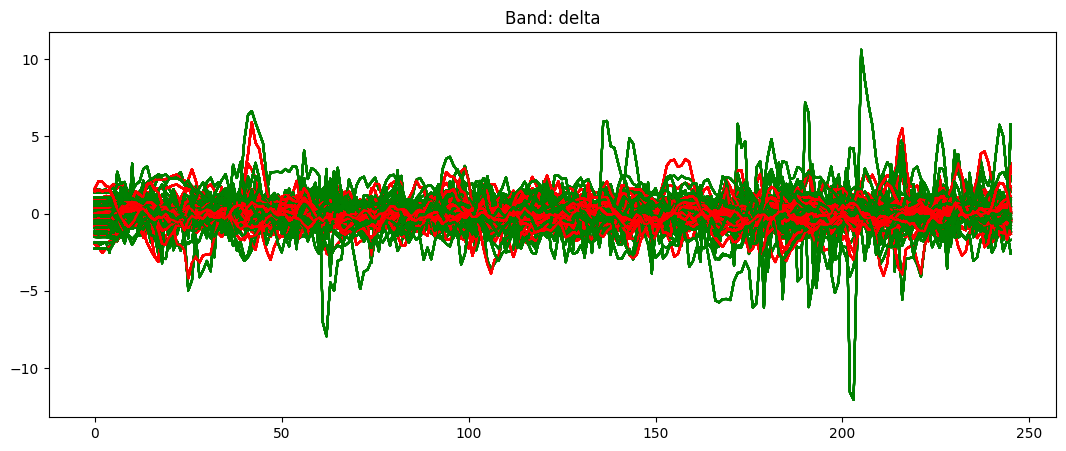

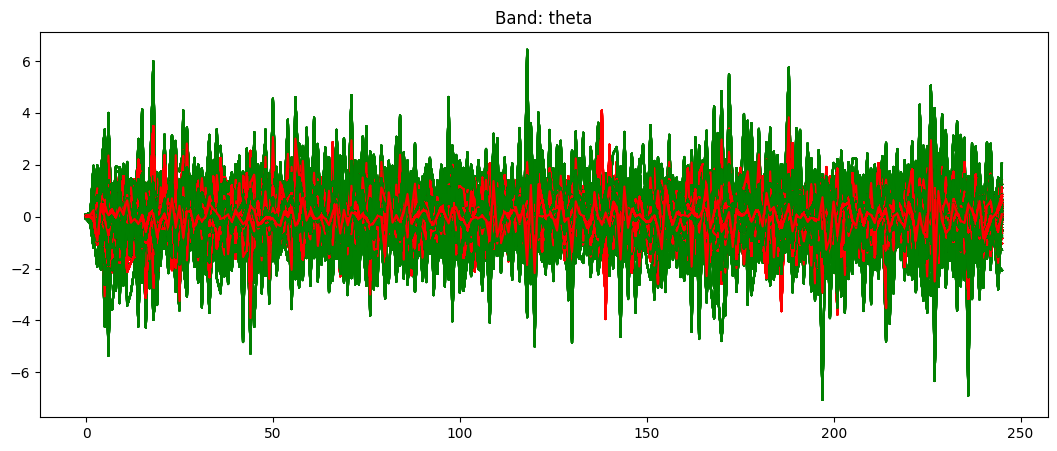

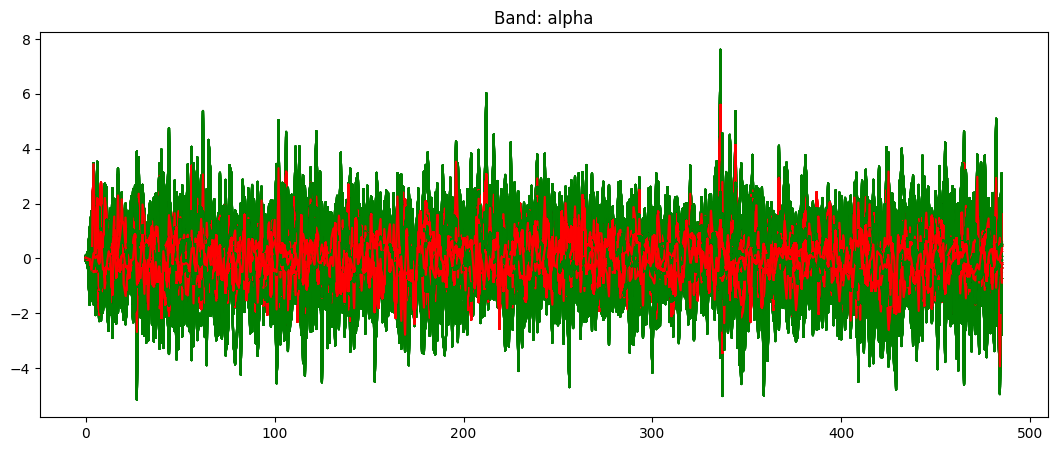

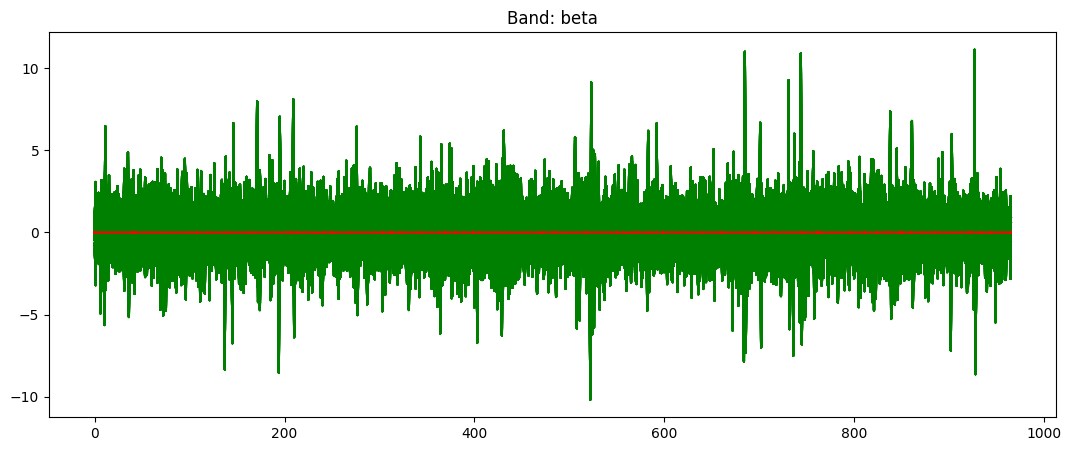

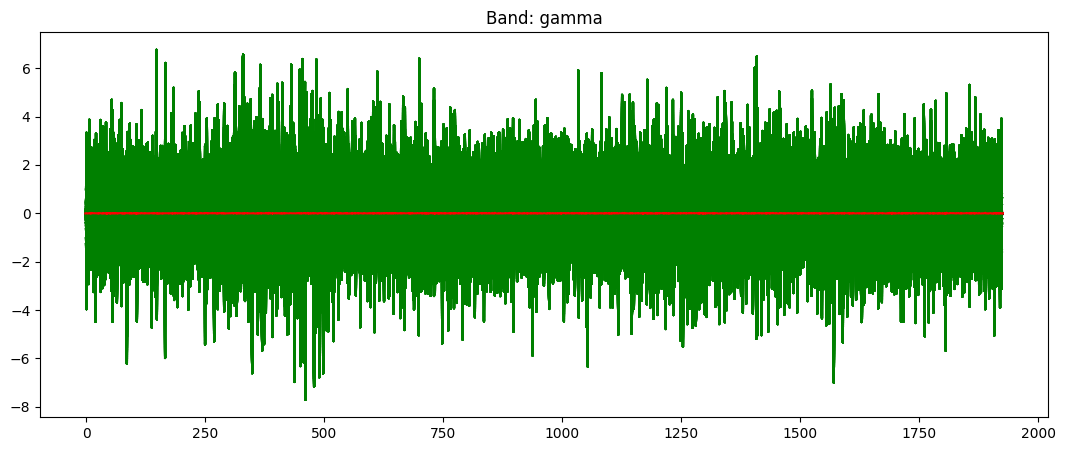

In [14]:
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(13, 5))
    for batch_idx in range(50):
        for channel in range(19):
            #if dropped_indexes[band][batch_idx, patch_idx, channel] == True:
            plt.plot(originals[band][batch_idx, :].cpu().detach().numpy(), label=f"Input {band} Channel {channel}", c="g")
            plt.plot(reconstructions[band][batch_idx, :].cpu().detach().numpy(), label=f"Output {band} Channel {channel}", c="r")
    plt.title(f"Band: {band}")
    plt.show()